In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sayan2807/soyabean-uav-image-dataset-whole")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sayan2807/soyabean-uav-image-dataset-whole


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 562.5 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 57.6 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, 

In [ ]:
# ============================================================
# CREATE UAV DATASET (FIRST 50 IMAGES PER CLASS)
# ============================================================

import os
import shutil

from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================

SOURCE_DATASET = "/kaggle/input/datasets/sayan2807/soyabean-uav-image-dataset-whole/Soyabean_UAV-Based_Image_Dataset"

OUTPUT_DATASET = "/kaggle/working/soybean_uav_first100_per_class"

# ============================================================
# SETTINGS
# ============================================================

IMAGES_PER_CLASS = 400

# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(OUTPUT_DATASET, exist_ok=True)

# ============================================================
# GET CLASS FOLDERS
# ============================================================

class_folders = [
    folder
    for folder in os.listdir(SOURCE_DATASET)
    if os.path.isdir(os.path.join(SOURCE_DATASET, folder))
]

class_folders = sorted(class_folders)

print("\nFound Classes:\n")

for cls in class_folders:
    print(cls)

# ============================================================
# COPY IMAGES
# ============================================================

summary = {}

overall_bar = tqdm(class_folders, desc="Creating Dataset")

for class_name in overall_bar:
    src_folder = os.path.join(SOURCE_DATASET, class_name)

    dst_folder = os.path.join(OUTPUT_DATASET, class_name)

    os.makedirs(dst_folder, exist_ok=True)

    image_files = [
        f
        for f in os.listdir(src_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    # ========================================================
    # SORT IMAGES
    # ========================================================

    image_files = sorted(image_files)

    # ========================================================
    # TAKE FIRST 50
    # ========================================================

    selected_images = image_files[:IMAGES_PER_CLASS]

    # ========================================================
    # COPY IMAGES
    # ========================================================

    for image_name in selected_images:
        src_path = os.path.join(src_folder, image_name)

        dst_path = os.path.join(dst_folder, image_name)

        shutil.copy2(src_path, dst_path)

    summary[class_name] = len(selected_images)

# ============================================================
# SUMMARY
# ============================================================

print("\n===================================================")

print("DATASET CREATED")

print("===================================================\n")

total = 0

for cls, count in summary.items():
    print(f"{cls:<35} : {count}")

    total += count

print()

print(f"Total Images : {total}")

print()

print("Saved To:")

print(OUTPUT_DATASET)


Found Classes:

Healthy_Soyabean
Soyabean Semilooper_Pest_Attack
Soyabean_Mosaic
rust


Creating Dataset: 100%|██████████| 4/4 [00:38<00:00,  9.63s/it]


DATASET CREATED

Healthy_Soyabean                    : 280
Soyabean Semilooper_Pest_Attack     : 400
Soyabean_Mosaic                     : 400
rust                                : 400

Total Images : 1480

Saved To:
/kaggle/working/soybean_uav_first100_per_class


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import cv2
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm

from PIL import Image

from ultralytics import YOLO

import torch.nn as nn

from torchvision import transforms
from torchvision.models import convnext_tiny

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ============================================================
# PATHS
# ============================================================

UAV_DATASET = "/kaggle/working/soybean_uav_first100_per_class"

YOLO_MODEL = (
    "/kaggle/input/models/sayan2807/yolo-v11-for-thesis/pytorch/default/1/best.pt"
)

# NEW FINETUNED MODEL
CONVNEXT_MODEL = "/kaggle/input/models/sayan2807/fine-tuned-conv-next-on-cropped-leaf-dataset/pytorch/default/1/uav_finetuned_convnext.pth"

OUTPUT_DIR = "/kaggle/working"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# GROUND TRUTH MAPPING
# ============================================================

GT_MAPPING = {
    "Healthy_Soyabean": "Healthy_Soybean",
    "rust": "Rust",
    "Soyabean_Mosaic": "Mosaic",
    "Soyabean Semilooper_Pest_Attack": "Caterpillar_and_Semilooper",
}

# ============================================================
# NEW 4 CLASS MODEL
# ============================================================

CLASS_NAMES = ["Healthy_Soybean", "Mosaic", "Rust", "Caterpillar_and_Semilooper"]

METRIC_CLASSES = CLASS_NAMES.copy()

# ============================================================
# YOLO SETTINGS
# ============================================================

CONF_THRESHOLD = 0.25

IOU_THRESHOLD = 0.50

MAX_DETECTIONS = 3000

TILE_SIZE = 640

OVERLAP = 0.30

MIN_AREA = 2500

MAX_AREA = 200000

MIN_ASPECT_RATIO = 0.3

MAX_ASPECT_RATIO = 3.0

# ============================================================
# LOAD YOLO
# ============================================================

print("\nLoading YOLO...")

yolo_model = YOLO(YOLO_MODEL)

print("YOLO Loaded")

# ============================================================
# LOAD FINETUNED UAV CONVNEXT
# ============================================================

print("\nLoading Fine-Tuned ConvNeXt...")

convnext = convnext_tiny(weights=None)

convnext.classifier[2] = nn.Linear(768, 4)

checkpoint = torch.load(CONVNEXT_MODEL, map_location=device)

convnext.load_state_dict(checkpoint)

convnext.to(device)

convnext.eval()

print("Fine-Tuned ConvNeXt Loaded")

# ============================================================
# TRANSFORMS
# ============================================================

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

print("\nSetup Complete")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda

Loading YOLO...
YOLO Loaded

Loading Fine-Tuned ConvNeXt...
Fine-Tuned ConvNeXt Loaded

Setup Complete


In [ ]:
# ============================================================
# YOLO LEAF EXTRACTION FUNCTION
# ============================================================


def extract_leaf_crops(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return []

    original = image.copy()

    H, W = image.shape[:2]

    stride = int(TILE_SIZE * (1 - OVERLAP))

    tiles = []

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            x2 = min(x + TILE_SIZE, W)

            y2 = min(y + TILE_SIZE, H)

            tile = image[y:y2, x:x2]

            if tile.shape[0] < TILE_SIZE or tile.shape[1] < TILE_SIZE:
                padded = np.zeros((TILE_SIZE, TILE_SIZE, 3), dtype=np.uint8)

                padded[: tile.shape[0], : tile.shape[1]] = tile

                tile = padded

            tiles.append((x, y, tile))

    all_boxes = []

    all_scores = []

    for offset_x, offset_y, tile in tiles:
        results = yolo_model.predict(
            source=tile,
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            imgsz=640,
            agnostic_nms=True,
            max_det=MAX_DETECTIONS,
            verbose=False,
        )

        result = results[0]

        boxes = result.boxes

        if boxes is None:
            continue

        for box in boxes:
            conf = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0]

            x1 = int(x1) + offset_x
            y1 = int(y1) + offset_y
            x2 = int(x2) + offset_x
            y2 = int(y2) + offset_y

            x1 = max(0, min(x1, W - 1))
            y1 = max(0, min(y1, H - 1))
            x2 = max(0, min(x2, W - 1))
            y2 = max(0, min(y2, H - 1))

            bw = x2 - x1
            bh = y2 - y1

            area = bw * bh

            if area < MIN_AREA:
                continue

            if area > MAX_AREA:
                continue

            aspect_ratio = bw / (bh + 1e-6)

            if aspect_ratio < MIN_ASPECT_RATIO:
                continue

            if aspect_ratio > MAX_ASPECT_RATIO:
                continue

            all_boxes.append([x1, y1, x2, y2])

            all_scores.append(conf)

    if len(all_boxes) == 0:
        return []

    indices = cv2.dnn.NMSBoxes(
        bboxes=[[b[0], b[1], b[2] - b[0], b[3] - b[1]] for b in all_boxes],
        scores=all_scores,
        score_threshold=CONF_THRESHOLD,
        nms_threshold=0.15,
    )

    leaf_crops = []

    if len(indices) > 0:
        for idx in indices.flatten():
            x1, y1, x2, y2 = all_boxes[idx]

            crop = original[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            leaf_crops.append(crop)

    return leaf_crops


# ============================================================
# QUICK TEST
# ============================================================

print("YOLO extraction function loaded.")

YOLO extraction function loaded.


In [ ]:
# ============================================================
# CONVNEXT CLASSIFICATION
# ============================================================


def classify_leaf(crop):

    image_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    image_pil = Image.fromarray(image_rgb)

    tensor = transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = convnext(tensor)

        probs = torch.softmax(logits, dim=1)

        probs = probs.cpu().numpy()[0]

    return probs


# ============================================================
# UAV IMAGE PREDICTION
# ============================================================


def predict_uav_image(image_path):

    leaf_crops = extract_leaf_crops(image_path)

    if len(leaf_crops) == 0:
        return None, None

    class_scores = np.zeros(4)

    for crop in leaf_crops:
        probs = classify_leaf(crop)

        class_scores += probs

    class_scores = class_scores / class_scores.sum()

    predicted_idx = np.argmax(class_scores)

    prediction = CLASS_NAMES[predicted_idx]

    return (prediction, class_scores)


print("ConvNeXt Aggregation Loaded")

ConvNeXt Aggregation Loaded


In [ ]:
# ============================================================
# UAV DATASET EVALUATION
# ============================================================

y_true = []
y_pred = []
y_score_vectors = []

total_images = 0

for folder_name in GT_MAPPING.keys():
    folder_path = os.path.join(UAV_DATASET, folder_name)

    if not os.path.exists(folder_path):
        continue

    images = [
        f
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    total_images += len(images)

print("\nTotal UAV Images:", total_images)

overall_bar = tqdm(total=total_images, desc="Evaluating UAV Dataset", unit="image")

for folder_name, gt_class in GT_MAPPING.items():
    folder_path = os.path.join(UAV_DATASET, folder_name)

    if not os.path.exists(folder_path):
        continue

    images = [
        f
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    for image_name in images:
        image_path = os.path.join(folder_path, image_name)

        try:
            prediction, score_vector = predict_uav_image(image_path)

            if prediction is None:
                overall_bar.update(1)

                continue

            y_true.append(gt_class)

            y_pred.append(prediction)

            y_score_vectors.append(score_vector)

        except Exception as e:
            print(f"\nError: {image_name}")

            print(e)

        overall_bar.update(1)

overall_bar.close()

y_score_vectors = np.array(y_score_vectors)

print("\nEvaluation Completed")

print("Ground Truth:", len(y_true))

print("Predictions:", len(y_pred))

print("Score Matrix:", y_score_vectors.shape)


Total UAV Images: 1480


Evaluating UAV Dataset: 100%|██████████| 1480/1480 [3:48:05<00:00,  9.25s/image]  


Evaluation Completed
Ground Truth: 1480
Predictions: 1480
Score Matrix: (1480, 4)




RESULTS
Accuracy  : 0.8453
Precision : 0.8975
Recall    : 0.8453
F1 Score  : 0.8416


CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Healthy_Soybean       1.00      0.54      0.70       400
                    Mosaic       0.96      1.00      0.98       280
                      Rust       0.65      1.00      0.79       400
Caterpillar_and_Semilooper       1.00      0.89      0.94       400

                  accuracy                           0.85      1480
                 macro avg       0.90      0.86      0.85      1480
              weighted avg       0.90      0.85      0.84      1480


ROC-AUC : 0.9821


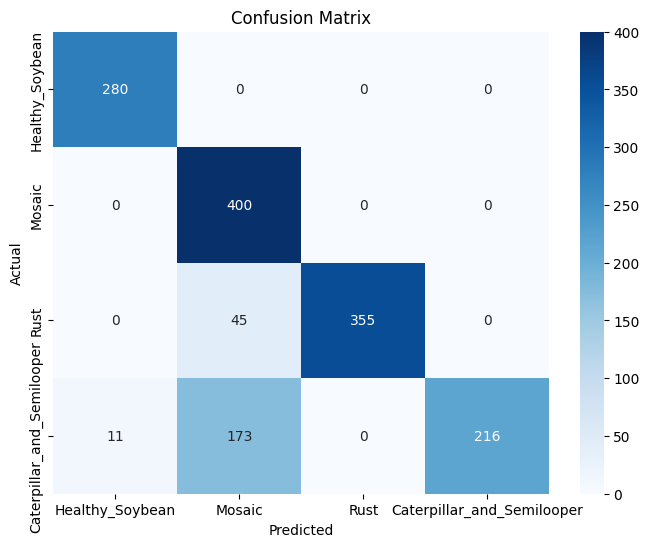

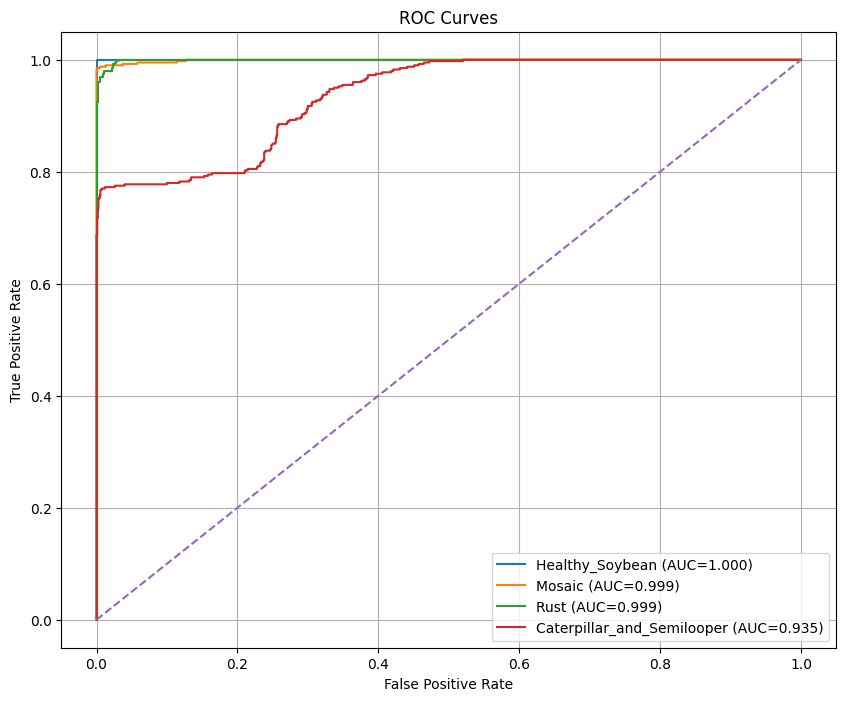


Saved: predictions.csv


In [ ]:
# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average="weighted")

recall = recall_score(y_true, y_pred, average="weighted")

f1 = f1_score(y_true, y_pred, average="weighted")

print("\n")
print("=" * 60)

print("RESULTS")

print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 60)

print("CLASSIFICATION REPORT")

print("=" * 60)

print(classification_report(y_true, y_pred, target_names=METRIC_CLASSES))

# ============================================================
# ROC AUC
# ============================================================

y_true_bin = label_binarize(y_true, classes=METRIC_CLASSES)

roc_auc = roc_auc_score(
    y_true_bin, y_score_vectors, multi_class="ovr", average="weighted"
)

print(f"\nROC-AUC : {roc_auc:.4f}")

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=METRIC_CLASSES)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=METRIC_CLASSES,
    yticklabels=METRIC_CLASSES,
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for i, cls in enumerate(METRIC_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score_vectors[:, i])

    roc_value = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_value:.3f})")

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid()

plt.show()

# ============================================================
# SAVE RESULTS
# ============================================================

pd.DataFrame({"GroundTruth": y_true, "Prediction": y_pred}).to_csv(
    "/kaggle/working/predictions.csv", index=False
)

print("\nSaved: predictions.csv")